# Base pseudo-code

In [35]:
import torch
from torch import nn, optim

def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi):
    model_t = f_theta_0
    theta_0 = [param.clone().detach() for param in f_theta_0.parameters()]
    mu = [torch.zeros_like(param, requires_grad=True) for param in theta_0]
    criterion = nn.KLDivLoss()
    optimizer = optim.LBFGS(mu, lr=eta_mu)

    for _ in range(T):
        with torch.no_grad():
            for param, theta, m in zip(model_t.parameters(), theta_0, mu):
                param.copy_((theta - xi * m).detach())

        upsilon = model_t(D_f)
        loss = criterion(upsilon, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu)

        loss.backward()
        optimizer.step()

    return model_t



# Code

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader, TensorDataset
import torch.nn.functional as F
from torch.nn.utils.stateless import functional_call
import copy
import random
import matplotlib.pyplot as plt


In [37]:
# ---- Transform ----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ---- Load datasets ----
train_dataset_full = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset_full = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

# ---- Forget Set ID----
def create_train_set(dataset, num_forget=0):
    forget_indices = random.sample(range(len(dataset)), num_forget)  # Randomly sample forget data
    D_f = Subset(dataset, forget_indices)  # Forget Set
    D_rest_indices = list(set(range(len(dataset))) - set(forget_indices))  # Rest of the data
    D_rest = Subset(dataset, D_rest_indices)  # Remaining training data

    # DataLoaders for each set
    forget_loader = DataLoader(D_f, batch_size=num_forget, shuffle=False)  # DataLoader for forget set
    train_loader = DataLoader(D_rest, batch_size=64, shuffle=True)  # DataLoader for remaining training data
    full_loader = DataLoader(dataset, batch_size=64, shuffle=True)  # DataLoader for the full training dataset

    return full_loader, train_loader, forget_loader 

def create_train_set_gaussian(dataset, contamination_ratio, subset_size=10000, plot_examples=False):
    # Limiter la taille du sous-ensemble
    raw_images = dataset.data[:subset_size].float() / 255.0
    raw_labels = dataset.targets[:subset_size]

    num_total = len(raw_images)
    num_contaminated = int(num_total * contamination_ratio)
    contaminated_indices = random.sample(range(num_total), num_contaminated)
    clean_indices = list(set(range(num_total)) - set(contaminated_indices))

    # Ajout du bruit gaussien
    def add_gaussian_noise(images, mean=0, std=0.2):
        noise = torch.randn_like(images) * std + mean
        noisy_images = torch.clamp(images + noise, 0.0, 1.0)
        return noisy_images, noise

    base_contaminated_images = raw_images[contaminated_indices]
    contaminated_images, noise = add_gaussian_noise(base_contaminated_images)

    clean_images = raw_images[clean_indices]

    # Normalisation
    #contaminated_images = (contaminated_images - 0.1307) / 0.3081
    #clean_images = (clean_images - 0.1307) / 0.3081
    #base_contaminated_images = (base_contaminated_images - 0.1307) / 0.3081
    #noise = noise / 0.3081  # Normaliser le bruit aussi pour qu'il corresponde aux images normalisées

    # Ajouter la dimension du canal
    contaminated_images = contaminated_images.unsqueeze(1)
    clean_images = clean_images.unsqueeze(1)
    base_contaminated_images = base_contaminated_images.unsqueeze(1)
    noise = noise.unsqueeze(1)

    # Concaténation des jeux de données
    train_images = torch.cat([clean_images, contaminated_images], dim=0)
    train_labels = torch.cat([raw_labels[clean_indices], raw_labels[contaminated_indices]], dim=0)

    # Datasets
    full_train_dataset = TensorDataset(train_images, train_labels)
    clean_train_dataset = TensorDataset(clean_images, raw_labels[clean_indices])
    contaminated_dataset = TensorDataset(contaminated_images, raw_labels[contaminated_indices])
    base_contaminated_dataset = TensorDataset(base_contaminated_images, raw_labels[contaminated_indices])
    noise_dataset = TensorDataset(noise, raw_labels[contaminated_indices])

    # Dataloaders
    full_loader = DataLoader(full_train_dataset, batch_size=64, shuffle=True)
    clean_loader = DataLoader(clean_train_dataset, batch_size=64, shuffle=True)
    contaminated_loader = DataLoader(contaminated_dataset, batch_size=num_contaminated, shuffle=False)
    base_contaminated_loader = DataLoader(base_contaminated_dataset, batch_size=1, shuffle=False)
    noise_loader = DataLoader(noise_dataset, batch_size=1, shuffle=False)

    if plot_examples:
        fig, axes = plt.subplots(1, 5, figsize=(10, 2))
        for i in range(5):
            axes[i].imshow(contaminated_images[i].squeeze(), cmap='gray')
            axes[i].set_title(f"Label: {raw_labels[contaminated_indices[i]].item()}")
            axes[i].axis('off')
        plt.suptitle("Exemples de données contaminées (bruit gaussien)")
        plt.show()

    return {
        "full_loader": full_loader,
        "clean_loader": clean_loader,
        "contaminated_loader": contaminated_loader,
        "base_contaminated_loader": base_contaminated_loader,
        "noise_loader": noise_loader
    }

# ---- Sample Set from Test Data ----
def create_test_set(dataset, subset_size=0, num_sample=0):
    
    sample_indices = random.sample(range(len(dataset)), num_sample)
    D_sample = Subset(dataset, sample_indices)
    D_test_rest_indices = list(set(range(len(dataset))) - set(sample_indices))
    D_test_rest = Subset(dataset, D_test_rest_indices)
    sample_loader = DataLoader(D_sample, batch_size=64, shuffle=False)
    test_loader = DataLoader(D_test_rest, batch_size=64, shuffle=False)
    return test_loader, sample_loader, sample_indices

# ---- Omega Set from Training Data ----
def create_omega_loader(dataset, proportion=0.01):
    num_omega = int(len(dataset) * proportion)
    omega_indices = random.sample(range(len(dataset)), num_omega)
    omega_subset = Subset(dataset, omega_indices)
    omega_loader = DataLoader(omega_subset, batch_size=1, shuffle=False, drop_last=False)
    return omega_loader, omega_indices

In [6]:
class FullyConnectedNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
def train_model(model, train_loader, lr, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

In [8]:
def compute_hessian_singular(model, images, labels, criterion):
    model.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    
    # Compute first-order gradients and track parameter shapes/sizes
    grad_params = torch.autograd.grad(loss, model.parameters(), create_graph=True)
    param_shapes = [p.shape for p in model.parameters()]
    param_sizes = [p.numel() for p in model.parameters()]
    
    # Flatten gradients and generate random vector
    flat_grad = torch.cat([g.view(-1) for g in grad_params])
    v = torch.randn_like(flat_grad)
    v = v / torch.norm(v)
    
    # Split flat vector `v` into parts matching parameter shapes
    v_split = []
    start = 0
    for size, shape in zip(param_sizes, param_shapes):
        end = start + size
        v_split.append(v[start:end].view(shape))
        start = end
    
    # Power iteration with split vectors
    for _ in range(3):
        hv = torch.autograd.grad(
            grad_params, 
            model.parameters(), 
            grad_outputs=v_split,  # Use split gradients
            retain_graph=True
        )
        # Flatten Hessian-vector product
        flat_hv = torch.cat([h.view(-1) for h in hv])
        v = flat_hv / torch.norm(flat_hv)
        
        # Re-split `v` for next iteration
        v_split = []
        start = 0
        for size, shape in zip(param_sizes, param_shapes):
            end = start + size
            v_split.append(v[start:end].view(shape))
            start = end
    
    sigma = torch.norm(flat_hv).item()
    return sigma

def train_model_with_unlearning_error(model, train_loader, lr, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    # Track initial weights
    initial_weights = [p.data.clone() for p in model.parameters()]
    
    # Trackers for unlearning error
    total_steps = 0
    sigma_sum = 0.0
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            
            # Compute Hessian singular value for this batch
            sigma = compute_hessian_singular(model, images, labels, criterion)
            sigma_sum += sigma
            
            epoch_loss += loss.item()
            total_steps += 1
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")
    
    # Compute unlearning error components
    final_weights = [p.data for p in model.parameters()]
    weight_diff = torch.cat([(fw - iw).view(-1) for fw, iw in zip(final_weights, initial_weights)])
    weight_diff_norm = torch.norm(weight_diff, p=2).item()  # ||w_t - w_0||_2
    
    sigma_avg = sigma_sum / total_steps  # Average Hessian singular value
    t = total_steps  # Total training steps
    
    # Unlearning error formula
    unlearning_error = (lr ** 2) * (weight_diff_norm / t) * sigma_avg * (t ** 2 - t) / 2
    
    print(f"\nUnlearning Error (e): {unlearning_error:.4f}")
    return model, unlearning_error

In [9]:
def verification_error(theta_0, theta_t):
    return torch.sqrt(sum(torch.norm(theta_0[name] - theta_t[name], p=2) ** 2 for name in theta_0))

In [10]:
def model_to_params(model): 
    return {name: param.clone().detach() for name, param in model.named_parameters()}

In [11]:
def forsaken(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi, optimizer, retrained_model = None, print_logs = True):
    model_t = copy.deepcopy(f_theta_0)
    theta_0 = model_to_params(model_t)
    log_verification_error = retrained_model != None
    if (log_verification_error):
        theta_retrained = model_to_params(retrained_model)
    mu = {name: torch.zeros_like(param, requires_grad=True) for name, param in theta_0.items()}
    criterion = nn.KLDivLoss(reduction='batchmean')

    P_expanded = P.unsqueeze(0).expand(D_f.size(0), -1)

    if optimizer == 'SGD':
        optimizer = optim.SGD(list(mu.values()), lr=eta_mu)
    elif optimizer == 'LBFGS':
        optimizer = optim.LBFGS(list(mu.values()), lr=eta_mu)

    loss_history = []
    verification_error_history = []

    last_loss = None  # Track the last computed loss
    last_verification_error = None # Track the last computed params
    def closure():
        nonlocal last_loss, last_verification_error, log_verification_error, theta_retrained
        optimizer.zero_grad()
        new_params = {name: theta_0[name] - xi * mu[name] for name in theta_0}
        upsilon = functional_call(model_t, new_params, D_f)
        log_probs = F.log_softmax(upsilon, dim=1)
        loss = criterion(log_probs, P_expanded) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu.values())
        loss.backward()
        last_loss = loss.item()
        if (log_verification_error):
            last_verification_error = verification_error(theta_retrained, new_params).item()
        return loss

    for _ in range(T):
        optimizer.step(closure)
        loss_history.append(last_loss)
        if (log_verification_error):
            verification_error_history.append(last_verification_error)
            if (print_logs):
                print(f"Iteration {_+1}, Loss: {last_loss:.4f}, Verification Error: {last_verification_error:.4f}")
        elif (print_logs):
            print(f"Iteration {_+1}, Loss: {last_loss:.4f}")

    # After optimization, update the model parameters
    final_params = {name: theta_0[name] - xi * mu[name].detach() for name in theta_0}
    for name, param in model_t.named_parameters():
            param.data.copy_(final_params[name])
    
    if (print_logs):
        print("Fin de la procédure Forsaken.")
    
        plt.plot(loss_history)
        plt.xlabel('Iteration')
        plt.ylabel('Forgetting loss')
        plt.title('Forgetting loss during Forsaken Optimization')
        plt.show()

        if (log_verification_error):
            plt.plot(verification_error_history)
            plt.xlabel('Iteration')
            plt.ylabel('Verification error')
            plt.title('Verification error during Forsaken Optimization')
            plt.show()

    return model_t


In [12]:
def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total

In [13]:
def compute_omega(model: nn.Module, D_0: DataLoader) -> float:
    model.eval()  # Disable dropout/batchnorm if present
    total_grad_norm = 0.0
    total_samples = 0
    
    for inputs, labels in D_0:
        
        # Process samples one-by-one for accurate per-sample gradients
        for i in range(inputs.size(0)):  
            model.zero_grad()
            
            # Forward pass
            output = model(inputs[i].unsqueeze(0))  # Add batch dimension
            loss = nn.functional.cross_entropy(output, labels[i].unsqueeze(0))
            
            # Backward pass
            loss.backward()
            
            # Compute L1 norm of gradients
            grad_norm = sum(
                p.grad.abs().sum().item() 
                for p in model.parameters() 
                if p.grad is not None
            )
            
            total_grad_norm += grad_norm
            total_samples += 1

    omega = total_grad_norm / total_samples if total_samples > 0 else 0.0
    return omega

In [14]:
def sample_P(model: nn.Module, P_loader: torch.utils.data.DataLoader):
    model.eval()
    all_posteriors = []
    
    with torch.no_grad():
        for inputs, _ in P_loader: 
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)  # Apply softmax
            all_posteriors.append(probabilities)
    
    all_posteriors = torch.cat(all_posteriors, dim=0)
    P = torch.mean(all_posteriors, dim=0)
    return P

In [15]:
def get_accuracy(model_forsaken, model_target, model_retrained, forget_loader, test_loader):
    
    accuracy_forget = evaluate_model(model_forsaken, forget_loader)
    print(f"Accuracy sur D_f après Forsaken : {accuracy_forget:.2f}%")

    accuracy_base = evaluate_model(model_target, forget_loader)
    print(f"Accuracy sur D_f sans Forsaken : {accuracy_base:.2f}%")

    accuracy_retrained = evaluate_model(model_retrained, forget_loader)
    print(f"Accuracy sur D_f avec réentraînement: {accuracy_retrained:.2f}%")

    accuracy_forget_test = evaluate_model(model_forsaken, test_loader)
    print(f"Accuracy sur base de test après Forsaken : {accuracy_forget_test:.2f}%")

    accuracy_base_test = evaluate_model(model_target, test_loader)
    print(f"Accuracy sur base de test sans Forsaken : {accuracy_base_test:.2f}%")

    accuracy_retrained_test = evaluate_model(model_retrained, test_loader)  
    print(f"Accuracy sur base de test avec réentraînement : {accuracy_retrained_test:.2f}%")

    return [accuracy_forget, accuracy_base, accuracy_retrained, accuracy_forget_test, accuracy_base_test, accuracy_retrained_test]


# Execution

## Example of ID forgetting

In [13]:
# ---- Create all datasets and loaders ----
full_loader, train_loader, forget_loader  = create_train_set(train_dataset_full, num_forget=100)
test_loader, sample_loader, sample_indices = create_test_set(test_dataset_full, num_sample=500)

# ---- Optional: print summary ----
print(f"Training set (excluding forget): {len(train_loader.dataset)}")
print(f"Forget set: {len(forget_loader.dataset)}")
print(f"Test set (excluding sample): {len(test_loader.dataset)}")
print(f"Sample set: {len(sample_loader.dataset)}")

Training set (excluding forget): 59900
Forget set: 100
Test set (excluding sample): 9500
Sample set: 500


In [17]:
model_target = FullyConnectedNN()
model_target, unlearning_error = train_model_with_unlearning_error(model_target, full_loader, 0.01, 5)

Epoch 1/5, Loss: 0.7683
Epoch 2/5, Loss: 0.3019
Epoch 3/5, Loss: 0.2471
Epoch 4/5, Loss: 0.2109
Epoch 5/5, Loss: 0.1831

Unlearning Error (e): 26.1695


In [14]:
model_retrained = FullyConnectedNN()
train_model(model_retrained, train_loader, 0.01, 5)

Epoch 1/5, Loss: 0.7887
Epoch 2/5, Loss: 0.3057
Epoch 3/5, Loss: 0.2485
Epoch 4/5, Loss: 0.2103
Epoch 5/5, Loss: 0.1816


In [15]:
P = sample_P(model_target, sample_loader)
print(P)
print(sum(P))

tensor([0.0992, 0.1368, 0.0913, 0.0941, 0.1271, 0.0786, 0.0842, 0.1049, 0.1025,
        0.0814])
tensor(1.)


Omega set: 599
Computed omega: 759.9154
Iteration 1, Loss: 6.3224, Verification Error: 18.1515
Iteration 2, Loss: 6.3135, Verification Error: 18.1515
Iteration 3, Loss: 6.3047, Verification Error: 18.1515
Iteration 4, Loss: 6.2958, Verification Error: 18.1515
Iteration 5, Loss: 6.2869, Verification Error: 18.1515
Iteration 6, Loss: 6.3133, Verification Error: 18.1515
Iteration 7, Loss: 6.2536, Verification Error: 18.1515
Iteration 8, Loss: 6.2480, Verification Error: 18.1515
Iteration 9, Loss: 6.2480, Verification Error: 18.1515
Iteration 10, Loss: 6.2480, Verification Error: 18.1515
Iteration 11, Loss: 6.2480, Verification Error: 18.1515
Iteration 12, Loss: 6.2480, Verification Error: 18.1515
Iteration 13, Loss: 6.2480, Verification Error: 18.1515
Iteration 14, Loss: 6.2480, Verification Error: 18.1515
Iteration 15, Loss: 6.2480, Verification Error: 18.1515
Iteration 16, Loss: 6.2480, Verification Error: 18.1515
Iteration 17, Loss: 6.2480, Verification Error: 18.1515
Iteration 18, Los

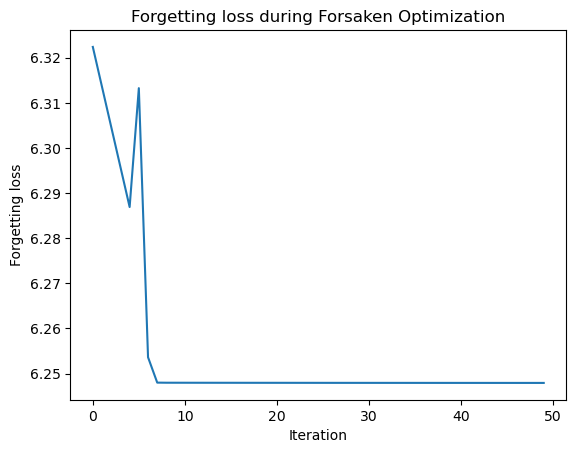

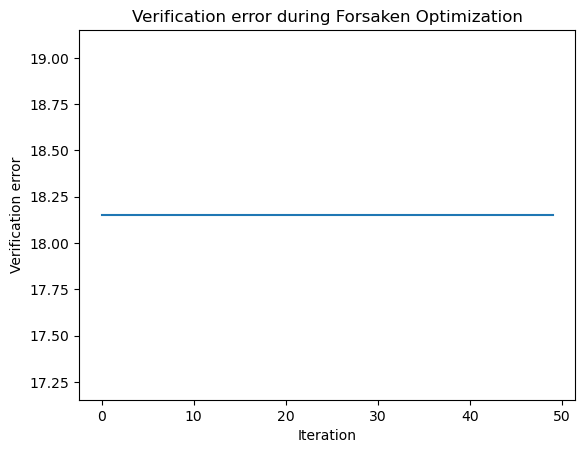

In [104]:
T = 50
lambda_ = 0.001
eta_mu = 0.01
xi = 0.01
p = 0.01

D_f, _ = next(iter(forget_loader))
omega_loader, omega_indices = create_omega_loader(train_loader.dataset, proportion=p)
print(f"Omega set: {len(omega_indices)}")
omega = compute_omega(model_target, omega_loader)
print(f"Computed omega: {omega:.4f}")

model_forsaken = forsaken(
    f_theta_0=model_target,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=D_f,
    eta_mu=eta_mu,
    xi=xi,
    optimizer = 'LBFGS',
    retrained_model = model_retrained
)


In [94]:
get_accuracy(model_forsaken, model_target, model_retrained, forget_loader, test_loader)

Accuracy sur D_f après Forsaken : 16.00%
Accuracy sur D_f sans Forsaken : 92.00%
Accuracy sur D_f avec réentraînement: 90.00%
Accuracy sur base de test après Forsaken : 11.82%
Accuracy sur base de test sans Forsaken : 95.13%
Accuracy sur base de test avec réentraînement : 94.95%


[16.0, 92.0, 90.0, 11.821052631578947, 95.12631578947368, 94.94736842105263]

## Hyperparameter search for ID data

In [32]:
param_grid = {
        "T": [10, 50],
        "lambda_": [0.001, 0.01, 0.1],
        "eta_mu": [0.001, 0.01, 0.1],
        "xi": [0.001, 0.01, 0.1],
        "p": [0.001, 0.01]
    }

In [33]:
import itertools
import pandas as pd

def hyperparameter_search(param_grid, model_target, forget_loader, test_loader, model_retrained):
    results = []
    params_retrained = model_to_params(model_retrained)
    iteration = 1
    for config_values in itertools.product(*param_grid.values()):
        print(f"Search n°{iteration}")
        iteration += 1
        config = dict(zip(param_grid.keys(), config_values))
        try:
            # Compute omega with current p value
            omega_loader, _ = create_omega_loader(
                train_loader.dataset, 
                proportion=config["p"]
            )
            omega = compute_omega(model_target, omega_loader)
            
            # Get forget batch
            D_f, _ = next(iter(forget_loader))
            
            # Run Forsaken
            unlearned_model = forsaken(
                f_theta_0=model_target,
                T=config["T"],
                lambda_=config["lambda_"],
                omega=omega,
                P=P,
                D_f=D_f,
                eta_mu=config["eta_mu"],
                xi=config["xi"],
                optimizer='LBFGS',
                retrained_model=model_retrained,
                print_logs=False
            )
            
            # Compute metrics
            forget_acc = evaluate_model(unlearned_model, forget_loader)
            test_acc = evaluate_model(unlearned_model, test_loader)
            verification_err = verification_error(params_retrained, model_to_params(unlearned_model))
            
            # Store results
            results.append({
                **config,
                "forget_acc": forget_acc,
                "test_acc": test_acc,
                "verification_err": verification_err
            })
            
        except Exception as e:
            print(f"Failed config {config}: {str(e)}")
            continue

    return pd.DataFrame(results)

In [34]:
search_results = hyperparameter_search(
    model_target=model_target,
    forget_loader=forget_loader,
    test_loader=test_loader,
    model_retrained=model_retrained,
    param_grid=param_grid
)

Search n°1


c:\Users\alici\anaconda3\lib\site-packages\torch\nn\utils\stateless.py:214: UserWarning: This API is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use torch.func.functional_call instead which is a drop-in replacement for this API.
  warnings.warn(


Search n°2
Search n°3
Search n°4
Search n°5
Search n°6
Search n°7
Search n°8
Search n°9
Search n°10
Search n°11
Search n°12
Search n°13
Search n°14
Search n°15
Search n°16
Search n°17
Search n°18
Search n°19
Search n°20
Search n°21
Search n°22
Search n°23
Search n°24
Search n°25
Search n°26
Search n°27
Search n°28
Search n°29
Search n°30
Search n°31
Search n°32
Search n°33
Search n°34
Search n°35
Search n°36
Search n°37
Search n°38
Search n°39
Search n°40
Search n°41
Search n°42
Search n°43
Search n°44
Search n°45
Search n°46
Search n°47
Search n°48
Search n°49
Search n°50
Search n°51
Search n°52
Search n°53
Search n°54
Search n°55
Search n°56
Search n°57
Search n°58
Search n°59
Search n°60
Search n°61
Search n°62
Search n°63
Search n°64
Search n°65
Search n°66
Search n°67
Search n°68
Search n°69
Search n°70
Search n°71
Search n°72
Search n°73
Search n°74
Search n°75
Search n°76
Search n°77
Search n°78
Search n°79
Search n°80
Search n°81
Search n°82
Search n°83
Search n°84
Search n°85


In [35]:
# Example analysis
print("\nTop 5 configurations by forget accuracy:")
print(search_results.sort_values('forget_acc').head(5))

print("\nConfigurations with test accuracy > 90%:")
print(search_results[search_results['test_acc'] > 90])

# Save full results
search_results.to_csv('unlearning_search_results.csv', index=False)


Top 5 configurations by forget accuracy:
     T  lambda_  eta_mu     xi      p  forget_acc  test_acc  \
51  10    0.100     0.1  0.010  0.010         2.0  7.031579   
13  10    0.001     0.1  0.001  0.010         3.0  9.705263   
86  50    0.010     0.1  0.010  0.001         5.0  9.105263   
30  10    0.010     0.1  0.001  0.001         7.0  9.684211   
49  10    0.100     0.1  0.001  0.010         7.0  6.105263   

      verification_err  
51   tensor(1427.5140)  
13    tensor(719.1661)  
86    tensor(628.6473)  
30   tensor(1827.8137)  
49  tensor(71935.7500)  

Configurations with test accuracy > 90%:
      T  lambda_  eta_mu     xi      p  forget_acc   test_acc verification_err
0    10    0.001   0.001  0.001  0.001        95.0  94.863158  tensor(18.0598)
1    10    0.001   0.001  0.001  0.010        95.0  94.863158  tensor(18.0598)
2    10    0.001   0.001  0.010  0.001        95.0  94.863158  tensor(18.0598)
3    10    0.001   0.001  0.010  0.010        95.0  94.863158  tensor(1

## Gaussian Poisoning

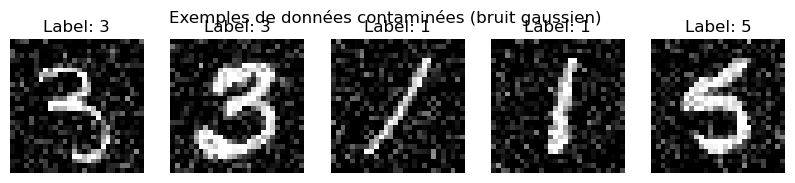

In [2]:
from torch.utils.data import TensorDataset

# Configuration
contamination_ratio = 0.6
subset_size = 10000  # Limiter à 10 000 images pour éviter surcharge mémoire

# Load MNIST (transform pas appliqué ici)
raw_dataset = datasets.MNIST(root="./data", train=True, download=True)
raw_images = raw_dataset.data[:subset_size].float() / 255.0
raw_labels = raw_dataset.targets[:subset_size]

# Déterminer les indices contaminés
num_total = len(raw_images)
num_contaminated = int(num_total * contamination_ratio)
contaminated_indices = random.sample(range(num_total), num_contaminated)
clean_indices = list(set(range(num_total)) - set(contaminated_indices))

# Fonction d'ajout de bruit
def add_gaussian_noise(images, mean=0, std=0.2):
    noise = torch.randn_like(images) * std + mean
    return torch.clamp(images + noise, 0.0, 1.0)

# Appliquer le bruit uniquement sur les images contaminées
contaminated_images = add_gaussian_noise(raw_images[contaminated_indices])
clean_images = raw_images[clean_indices]

# Normalisation manuelle
contaminated_images = (contaminated_images - 0.1307) / 0.3081
clean_images = (clean_images - 0.1307) / 0.3081

# Ajouter la dimension canal
contaminated_images = contaminated_images.unsqueeze(1)
clean_images = clean_images.unsqueeze(1)

# Fusion des datasets
train_images = torch.cat([clean_images, contaminated_images], dim=0)
train_labels = torch.cat([raw_labels[clean_indices], raw_labels[contaminated_indices]], dim=0)

# Création des dataloaders
noisy_train_dataset = TensorDataset(train_images, train_labels)
noisy_train_loader = DataLoader(noisy_train_dataset, batch_size=64, shuffle=True)

# Forget set = uniquement les contaminés
forget_dataset = TensorDataset(contaminated_images, raw_labels[contaminated_indices])
forget_loader = DataLoader(forget_dataset, batch_size=64, shuffle=False)

# Affichage de quelques exemples
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(contaminated_images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {raw_labels[contaminated_indices[i]].item()}")
    axes[i].axis('off')
plt.suptitle("Exemples de données contaminées (bruit gaussien)")
plt.show()


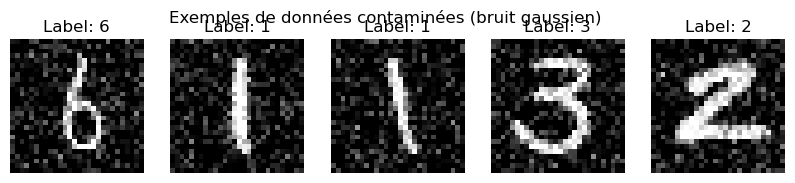

Taille du dataset total: 10000
Taille du dataset clean: 4000
Taille du dataset corrompu: 6000, 6000, 6000


In [41]:
loaders = create_train_set_gaussian(train_dataset_full, 0.6, 10000, True)
print(f"Taille du dataset total: {len(loaders['full_loader'].dataset)}")
print(f"Taille du dataset clean: {len(loaders['clean_loader'].dataset)}")
print(f"Taille du dataset corrompu: {len(loaders['contaminated_loader'].dataset)}, "
      f"{len(loaders['base_contaminated_loader'].dataset)}, {len(loaders['noise_loader'].dataset)}")


In [ ]:
model_noise = FullyConnectedNN()
#train_model(model_noise, train_loader=noisy_train_loader, lr=0.01, epochs=25)
model_noise, unlearning_error_noise = train_model_with_unlearning_error(model_noise, loaders["full_loader"], 0.01, 25)

In [31]:
model_clean = FullyConnectedNN()
train_model(model_clean, loaders["clean_loader"], 0.01, 25)

Epoch 1/25, Loss: 2.2978
Epoch 2/25, Loss: 2.2754
Epoch 3/25, Loss: 2.2472
Epoch 4/25, Loss: 2.2086
Epoch 5/25, Loss: 2.1543
Epoch 6/25, Loss: 2.0776
Epoch 7/25, Loss: 1.9721
Epoch 8/25, Loss: 1.8284
Epoch 9/25, Loss: 1.6496
Epoch 10/25, Loss: 1.4438
Epoch 11/25, Loss: 1.2452
Epoch 12/25, Loss: 1.0761
Epoch 13/25, Loss: 0.9466
Epoch 14/25, Loss: 0.8446
Epoch 15/25, Loss: 0.7685
Epoch 16/25, Loss: 0.7059
Epoch 17/25, Loss: 0.6565
Epoch 18/25, Loss: 0.6185
Epoch 19/25, Loss: 0.5820
Epoch 20/25, Loss: 0.5557
Epoch 21/25, Loss: 0.5318
Epoch 22/25, Loss: 0.5078
Epoch 23/25, Loss: 0.4910
Epoch 24/25, Loss: 0.4725
Epoch 25/25, Loss: 0.4582


In [32]:
test_loader_gaussian, sample_loader_gaussian, sample_indices_gaussian = create_test_set(test_dataset_full, num_sample=500)

In [33]:
P = sample_P(model_noise, sample_loader_gaussian)
print(P)
print(sum(P))


tensor([0.1133, 0.1062, 0.0837, 0.1062, 0.1020, 0.0721, 0.0902, 0.1117, 0.1036,
        0.1110])
tensor(1.)


C:\Users\mathi\AppData\Local\Temp\ipykernel_10952\560380032.py:17: FutureWarning: `torch.nn.utils.stateless.functional_call` is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use `torch.func.functional_call` instead which is a drop-in replacement.
  upsilon = functional_call(model_t, new_params, D_f)


Loss: 7.263974189758301
Loss: 7.2447357177734375
Loss: 4.260101795196533
Loss: 3.2894437313079834
Loss: 2.4212167263031006
Loss: 1.7800894975662231
Loss: 1.3690416812896729
Loss: 1.0644179582595825
Loss: 0.7985745072364807
Loss: 0.5835450291633606
Loss: 0.4077911078929901
Loss: 0.2744767665863037
Loss: 0.1790204644203186
Loss: 0.11738462746143341
Loss: 0.08112159371376038
Loss: 0.05966680496931076
Loss: 0.04731171205639839
Loss: 0.037826474756002426
Loss: 0.029957391321659088
Loss: 0.02257116511464119
Loss: 0.01753918081521988
Loss: 0.013948826119303703
Loss: 0.010428323410451412
Loss: 0.00827980600297451
Loss: 0.006540259812027216
Loss: 0.005412780214101076
Loss: 0.004481127951294184
Loss: 0.003640906186774373
Loss: 0.002955665113404393
Loss: 0.00253749149851501
Loss: 0.0020941030234098434
Loss: 0.0016936678439378738
Loss: 0.0014525637961924076
Loss: 0.0012659074272960424
Loss: 0.0009820552077144384
Loss: 0.0008478241506963968
Loss: 0.0007426280062645674
Loss: 0.00065195607021451
Loss

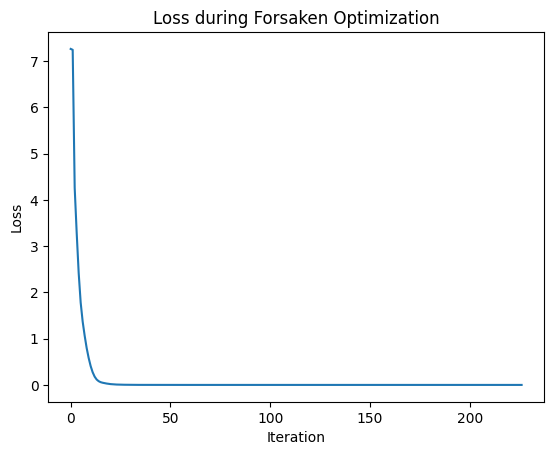

In [108]:
T = 100
lambda_ = 0
omega = 1.0
eta_mu = 0.2
xi = 3.0

model_forsaken_noise = forsaken(
    f_theta_0=model_noise,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=images_forget,  # batch d’images à oublier
    eta_mu=eta_mu,
    xi=xi,
    optimizer='LBFGS'
)


Omega set: 40
Computed omega: 554.7285


c:\Users\alici\anaconda3\lib\site-packages\torch\nn\utils\stateless.py:214: UserWarning: This API is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use torch.func.functional_call instead which is a drop-in replacement for this API.
  warnings.warn(


Iteration 1, Loss: 5.9532, Verification Error: 18.4909
Iteration 2, Loss: 5.8937, Verification Error: 18.4909
Iteration 3, Loss: 8.7456, Verification Error: 18.4908
Iteration 4, Loss: 3671.1680, Verification Error: 18.5514
Iteration 5, Loss: 783.0059, Verification Error: 18.5006
Iteration 6, Loss: 574.8162, Verification Error: 18.4963
Iteration 7, Loss: 483.4716, Verification Error: 18.4943
Iteration 8, Loss: 429.4780, Verification Error: 18.4930
Iteration 9, Loss: 399.0542, Verification Error: 18.4924
Iteration 10, Loss: 382.6504, Verification Error: 18.4921
Iteration 11, Loss: 373.2663, Verification Error: 18.4919
Iteration 12, Loss: 367.3376, Verification Error: 18.4918
Iteration 13, Loss: 363.7204, Verification Error: 18.4917
Iteration 14, Loss: 361.4196, Verification Error: 18.4916
Iteration 15, Loss: 359.9140, Verification Error: 18.4916
Iteration 16, Loss: 358.8690, Verification Error: 18.4916
Iteration 17, Loss: 358.1704, Verification Error: 18.4916
Iteration 18, Loss: 357.6584

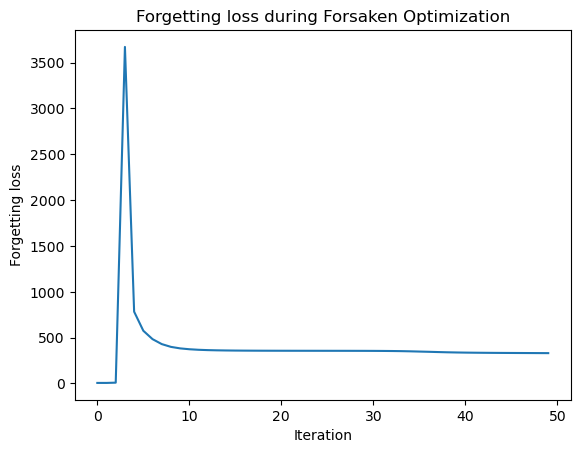

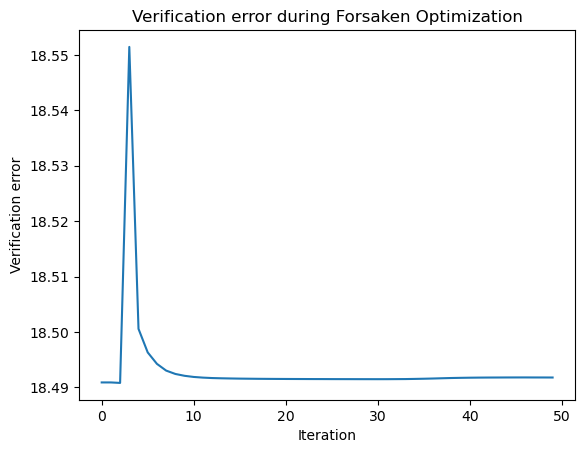

In [34]:
T = 50
lambda_ = 0.001
eta_mu = 0.01
xi = 0.01
p = 0.01

D_f, _ = next(iter(loaders["contaminated_loader"]))
omega_loader, omega_indices = create_omega_loader(loaders["clean_loader"].dataset, proportion=p)
print(f"Omega set: {len(omega_indices)}")
omega = compute_omega(model_noise, omega_loader)
print(f"Computed omega: {omega:.4f}")

model_forsaken = forsaken(
    f_theta_0=model_noise,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=D_f,
    eta_mu=eta_mu,
    xi=xi,
    optimizer = 'LBFGS',
    retrained_model = model_clean
)


In [36]:
get_accuracy(model_forsaken, model_noise, model_clean, loaders["contaminated_loader"], test_loader_gaussian)


Accuracy sur D_f après Forsaken : 91.62%
Accuracy sur D_f sans Forsaken : 91.67%
Accuracy sur D_f avec réentraînement: 85.08%
Accuracy sur base de test après Forsaken : 89.79%
Accuracy sur base de test sans Forsaken : 89.78%
Accuracy sur base de test avec réentraînement : 83.89%


[91.61666666666666,
 91.66666666666667,
 85.08333333333333,
 89.78947368421052,
 89.77894736842106,
 83.89473684210526]

### Label Poisoning 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy
import random
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split, Subset
from torch.nn.utils.stateless import functional_call
import torchvision
import torchvision.transforms as transforms


C:\Users\mathi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader
import random

# ---------------------------
# 1. Chargement et transformation
# ---------------------------
transform = transforms.ToTensor()

# Chargement du dataset d'entraînement MNIST
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Chargement du dataset de test MNIST (clean)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# ---------------------------
# 2. Application de la corruption sur l'ensemble d'entraînement uniquement
# ---------------------------
corrupted_train_images = []
corrupted_train_labels = []
corrupted_train_flags = []  # True si l'exemple est corrompu

for img, label in mnist_train:
    # Pour chaque image de label 1, on change le label en 7 avec 50 % de chance.
    if label == 1 and random.random() < 0.6:
        new_label = 7
        corrupted_train_flags.append(True)
    else:
        new_label = label
        corrupted_train_flags.append(False)
    corrupted_train_images.append(img)
    corrupted_train_labels.append(new_label)

# Création d'un TensorDataset pour l'ensemble d'entraînement corrompu
data_tensor_train = torch.stack(corrupted_train_images)        # (N, 1, 28, 28)
labels_tensor_train = torch.tensor(corrupted_train_labels)       # (N,)
flags_tensor_train = torch.tensor(corrupted_train_flags)         # (N,)

corrupted_train_dataset = TensorDataset(data_tensor_train, labels_tensor_train, flags_tensor_train)

# Pour le test, on utilise directement le dataset clean
clean_test_dataset = mnist_test

# ---------------------------
# 3. Création des DataLoaders
# ---------------------------
corrupted_train_loader = DataLoader(corrupted_train_dataset, batch_size=64, shuffle=True)
clean_test_loader = DataLoader(clean_test_dataset, batch_size=64, shuffle=False)

# ---------------------------
# 4. Vérification (optionnelle)
# ---------------------------
def count_corrupted(dataset):
    count = 0
    for sample in dataset:
        # Chaque échantillon est (image, label, flag)
        if sample[2]:
            count += 1
    return count

print("Nombre total d'exemples dans l'ensemble d'entraînement :", len(corrupted_train_dataset))
print("Nombre d'exemples corrompus dans l'ensemble d'entraînement :", count_corrupted(corrupted_train_dataset))
print("Nombre total d'exemples dans l'ensemble de test :", len(clean_test_dataset))


Nombre total d'exemples dans l'ensemble d'entraînement : 60000
Nombre d'exemples corrompus dans l'ensemble d'entraînement : 3982
Nombre total d'exemples dans l'ensemble de test : 10000


In [16]:

# =============================================================================
# 3. Définition du modèle et des fonctions
# =============================================================================

class FullyConnectedNN(nn.Module):
    def __init__(self):
        super(FullyConnectedNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def train_model_corrupted(model, train_loader, lr, epochs):
    """Adapté pour gérer des tuples (images, labels, flag)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            # Le dataset renvoie trois éléments : (images, labels, flag)
            if len(batch) == 3:
                images, labels, _ = batch
            else:
                images, labels = batch
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")


def forget_set_corrupted(dataset, num_forget=100):
    """Sélectionne uniquement les indices correspondant aux points corrompus."""
    corrupted_indices = [i for i in range(len(dataset)) if dataset[i][2]]
    if len(corrupted_indices) == 0:
        raise ValueError("Aucun point corrompu n'a été trouvé dans le dataset.")
    forget_indices = random.sample(corrupted_indices, min(num_forget, len(corrupted_indices)))
    D_f = Subset(dataset, forget_indices)
    forget_loader = DataLoader(D_f, batch_size=64, shuffle=False)
    return forget_loader, D_f

def evaluate_model_corrupted(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in data_loader:
            if len(batch) == 3:
                images, labels, _ = batch
            else:
                images, labels = batch
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return 100 * correct / total


In [5]:
# =============================================================================
# 4. Entraînement du modèle sur le dataset corrompu
# =============================================================================
model_corrupted = FullyConnectedNN()
train_model_corrupted(model_corrupted, corrupted_train_loader, lr=0.01, epochs=5)

Epoch 1/5, Loss: 1.7223
Epoch 2/5, Loss: 0.6438
Epoch 3/5, Loss: 0.4802
Epoch 4/5, Loss: 0.4235
Epoch 5/5, Loss: 0.3891


In [18]:
def forsaken_corrupted(f_theta_0, T, lambda_, omega, P, D_f, eta_mu, xi, optimizer):
    model_t = copy.deepcopy(f_theta_0)
    theta_0 = {name: param.clone().detach() for name, param in model_t.named_parameters()}
    mu = {name: torch.zeros_like(param, requires_grad=True) for name, param in theta_0.items()}
    criterion = nn.KLDivLoss(reduction='batchmean')

    if optimizer == 'SGD':
        optimizer = optim.SGD(list(mu.values()), lr=eta_mu)
    elif optimizer == 'LBFGS':
        optimizer = optim.LBFGS(list(mu.values()), lr=eta_mu)

    loss_history = []
    verification_error_history = []

    last_loss = None  # Track the last computed loss
    last_verification_error = None # Track the last computed params
    def closure():
        nonlocal last_loss, last_verification_error
        optimizer.zero_grad()
        new_params = {name: theta_0[name] - xi * mu[name] for name in theta_0}
        upsilon = functional_call(model_t, new_params, D_f)
        log_probs = F.log_softmax(upsilon, dim=1)
        loss = criterion(log_probs, P) + lambda_ * omega * sum(torch.norm(m, p=1) for m in mu.values())
        loss.backward()
        last_loss = loss.item()
        last_verification_error = verification_error(theta_0, new_params).item()
        
        return loss


    for _ in range(T):
        optimizer.step(closure)
        loss_history.append(last_loss)
        verification_error_history.append(last_verification_error)
        print(f"Iteration {_+1}, Loss: {last_loss:.4f}, Verification Error: {last_verification_error:.4f}")


    # After optimization, update the model parameters
    final_params = {name: theta_0[name] - xi * mu[name].detach() for name in theta_0}
    for name, param in model_t.named_parameters():
            param.data.copy_(final_params[name])
    
    print("Fin de la procédure Forsaken.")
    
    plt.plot(loss_history)
    plt.xlabel('Iteration')
    plt.ylabel('Forgetting loss')
    plt.title('Forgetting loss during Forsaken Optimization')
    plt.show()

    plt.plot(verification_error_history)
    plt.xlabel('Iteration')
    plt.ylabel('Verification error')
    plt.title('Verification during Forsaken Optimization')
    plt.show()

    return model_t


C:\Users\mathi\AppData\Local\Temp\ipykernel_31040\530317116.py:21: FutureWarning: `torch.nn.utils.stateless.functional_call` is deprecated as of PyTorch 2.0 and will be removed in a future version of PyTorch. Please use `torch.func.functional_call` instead which is a drop-in replacement.
  upsilon = functional_call(model_t, new_params, D_f)


Iteration 1, Loss: 3.6574, Verification Error: 0.0732
Iteration 2, Loss: 3.5664, Verification Error: 0.1096
Iteration 3, Loss: 3.4611, Verification Error: 0.1353
Iteration 4, Loss: 3.3772, Verification Error: 0.1507
Iteration 5, Loss: 3.3137, Verification Error: 0.1644
Iteration 6, Loss: 3.2632, Verification Error: 0.1780
Iteration 7, Loss: 3.2351, Verification Error: 0.1848
Iteration 8, Loss: 3.2024, Verification Error: 0.1842
Iteration 9, Loss: 3.1788, Verification Error: 0.1951
Iteration 10, Loss: 3.1557, Verification Error: 0.1986
Iteration 11, Loss: 3.1283, Verification Error: 0.2038
Iteration 12, Loss: 3.1124, Verification Error: 0.2095
Iteration 13, Loss: 3.0926, Verification Error: 0.2168
Iteration 14, Loss: 3.0771, Verification Error: 0.2196
Iteration 15, Loss: 3.0632, Verification Error: 0.2236
Iteration 16, Loss: 3.0486, Verification Error: 0.2265
Iteration 17, Loss: 3.0354, Verification Error: 0.2327
Iteration 18, Loss: 3.0215, Verification Error: 0.2330
Iteration 19, Loss:

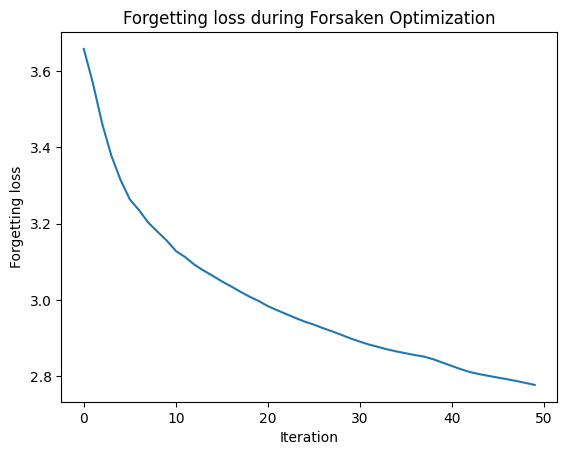

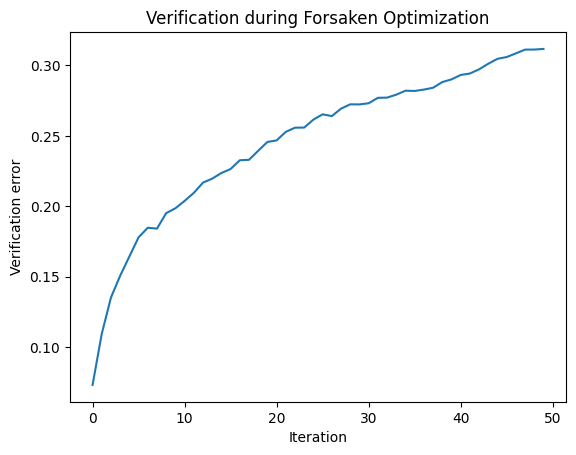

In [19]:

# =============================================================================
# 5. Création du forget set ciblé sur les points corrompus
# =============================================================================
forget_loader_corrupted, D_f_corrupted = forget_set_corrupted(corrupted_train_dataset)
images_forget, labels_forget, _ = next(iter(forget_loader_corrupted))
# Création d'une distribution uniforme pour P (pour la KL-divergence)
P = torch.full((images_forget.size(0), 10), 1/10)

# =============================================================================
# 6. Application de la procédure Forsaken
# =============================================================================
T = 50
lambda_ = 0.1
omega = 1.0
eta_mu = 0.2
xi = 1.0

model_corrupted_forsaken = forsaken_corrupted(
    f_theta_0=model_corrupted,
    T=T,
    lambda_=lambda_,
    omega=omega,
    P=P,
    D_f=images_forget,  # Batch d'images du forget set
    eta_mu=eta_mu,
    xi=xi,
    optimizer='LBFGS'
)


In [21]:

# =============================================================================
# 7. Évaluation du modèle avant et après Forsaken
# =============================================================================
accuracy_forget_corrupted = evaluate_model_corrupted(model_corrupted_forsaken, forget_loader_corrupted)
print(f"Accuracy sur D_f corrompu après Forsaken : {accuracy_forget_corrupted:.2f}%")

accuracy_base_corrupted = evaluate_model_corrupted(model_corrupted, forget_loader_corrupted)
print(f"Accuracy sur D_f corrompu sans Forsaken : {accuracy_base_corrupted:.2f}%")

accuracy_forget_test_corrupted = evaluate_model_corrupted(model_corrupted_forsaken, clean_test_loader)
print(f"Accuracy sur base de test corrompue après Forsaken : {accuracy_forget_test_corrupted:.2f}%")

accuracy_base_test_corrupted = evaluate_model_corrupted(model_corrupted, clean_test_loader)
print(f"Accuracy sur base de test corrompue sans Forsaken : {accuracy_base_test_corrupted:.2f}%")

Accuracy sur D_f corrompu après Forsaken : 24.00%
Accuracy sur D_f corrompu sans Forsaken : 87.00%
Accuracy sur base de test corrompue après Forsaken : 83.86%
Accuracy sur base de test corrompue sans Forsaken : 82.42%
